# Fashion MNIST Classification with Keras

### Purpose
This notebook demonstrates the process of building and training neural networks using Keras and TensorFlow to classify images from the Fashion MNIST dataset. It covers data loading, preprocessing, model architecture design, training with different optimizers, and evaluation, including the use of advanced training techniques like callbacks for improved performance.

**Experiment Link** -->https://colab.research.google.com/drive/1y_tSrMFjkkIYg0k3TXtGhkX1I1UFXm6t?usp=sharing

## 1. Setup and Library Imports
This section imports all the necessary libraries and modules for data handling, model building, and visualization.

In [55]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Dense,Flatten,Dropout

## 2. Data Loading and Initial Exploration
Here, we load the Fashion MNIST dataset, which consists of 70,000 grayscale images of 10 fashion categories. We then perform some initial checks on the data shape and visualize a sample image.

### 2.1 Data Description
This table provides a mapping of the numerical labels to their corresponding fashion item class names in the Fashion MNIST dataset.

DATA DESCRIPTION


| Label | Class Name      | Description          |
| :---: | :-------------- | :------------------- |
|   0   | **T-shirt/top** | Short-sleeved top    |
|   1   | **Trouser**     | Pants                |
|   2   | **Pullover**    | Long-sleeved sweater |
|   3   | **Dress**       | One-piece dress      |
|   4   | **Coat**        | Overcoat or jacket   |
|   5   | **Sandal**      | Open shoe            |
|   6   | **Shirt**       | Button-down shirt    |
|   7   | **Sneaker**     | Sports shoe          |
|   8   | **Bag**         | Handbag or tote      |
|   9   | **Ankle boot**  | Boot or shoe         |


In [22]:
(x_train,y_train),(x_test,y_test)= fashion_mnist.load_data()

## 3. Data Preprocessing
This section focuses on preparing the data for the neural network. This includes normalization of pixel values and flattening the image data for use with dense layers.

In [23]:
x_train.shape,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [24]:
y_train.shape,y_test.shape

((60000,), (10000,))

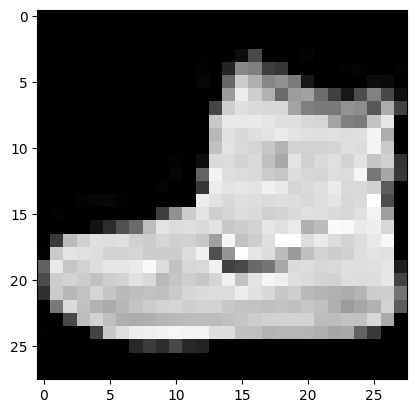

In [25]:
# Each data point is nothing but a pixel value
plt.imshow(x_train[0],cmap='gray')

In [26]:
for i in x_train[0]:
  print(i)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  1  0  0 13 73  0  0  1  4  0  0  0
  0  1  1  0]
[  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
  54   0   0   0   1   3   4   0   0   3]
[  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
 144 123  23   0   0   0   0  12  10   0]
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
 107 156 161 109  64  23  77 130  72  15]
[  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
 216 163 127 121 122 146 141  88 172  66]
[  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229
 223 223 215 213 164 127 123 196 229   0]
[  0   0   0   0   0   0   0   0   0   0   0   0   0 183 225 216 223 228
 235 227 224 222 224 221 223 245 173   0]
[  0   0   0   0   0   0   0   0   0   0   0   0 

In [27]:
# checking for output
def look_data(idx):
  print(f"y_lable:",y_train[idx])
  plt.imshow(x_train[idx],cmap='gray')

y_lable: 3


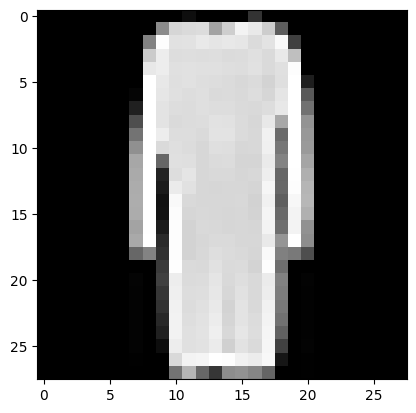

In [28]:
look_data(25)

y_lable: 0


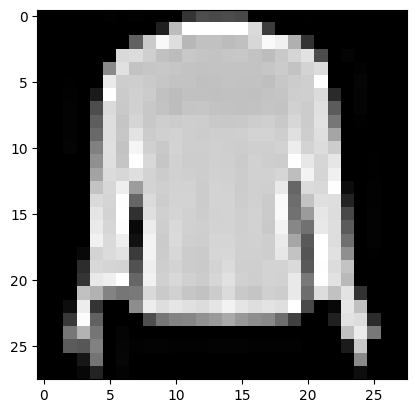

In [29]:
look_data(169)

### 3.1 Normalization
We scale the pixel values of the training and test images from the range [0, 255] to [0, 1]. This helps in faster convergence during training and improves model performance.

In [30]:
# Resclae the data
max(x_train[00].flatten()),min(x_train[00].flatten())

(np.uint8(255), np.uint8(0))

In [31]:
# Normalize
x_train = x_train/255.0
x_test = x_test/255.0

In [32]:
# Resclae the data
max(x_train[00].flatten()),min(x_train[00].flatten())

(np.float64(1.0), np.float64(0.0))

## 4. Model 1: Simple Dense Network (Original non-flattened input)
This section defines, compiles, trains, and evaluates a simple sequential neural network. The input images are flattened by a dedicated `Flatten` layer within the model.

### 4.1 Model Architecture
We define a `tf.keras.Sequential` model with a `Flatten` layer to convert 2D images to 1D, followed by two `Dense` hidden layers with ReLU activation, and a final `Dense` output layer with softmax activation for classification.

In [35]:
# Build Keras model without flatenning the data
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)), # Explicitly define the input shape
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

### 4.2 Model Compilation
The model is compiled using the Adam optimizer, `sparse_categorical_crossentropy` loss function (suitable for integer labels), and 'accuracy' as the evaluation metric.

In [36]:
#compiling
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics =['accuracy'])

### 4.3 Model Training
 The model is trained on the `x_train` and `y_train` data for 10 epochs, with validation performed on the `x_test` and `y_test` sets.

In [37]:
#training
history = model.fit(x_train,y_train,epochs = 10,validation_data = (x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8248 - loss: 0.4903 - val_accuracy: 0.8517 - val_loss: 0.4119
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8661 - loss: 0.3663 - val_accuracy: 0.8544 - val_loss: 0.4046
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8783 - loss: 0.3303 - val_accuracy: 0.8634 - val_loss: 0.3811
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8855 - loss: 0.3095 - val_accuracy: 0.8673 - val_loss: 0.3715
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8902 - loss: 0.2923 - val_accuracy: 0.8770 - val_loss: 0.3406
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8971 - loss: 0.2777 - val_accuracy: 0.8808 - val_loss: 0.3357
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8990 - loss: 0.2668 - val_accuracy: 0.8800 - val_loss: 0.3407
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9052 - loss: 0.2548

### 4.4 Model Evaluation and Visualization
After training, the model's performance is evaluated on the test set. The training history (loss and accuracy) is then visualized to observe the model's learning progress.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 0.3479
Test Loss: 0.3479
Test Accuracy: 0.8786


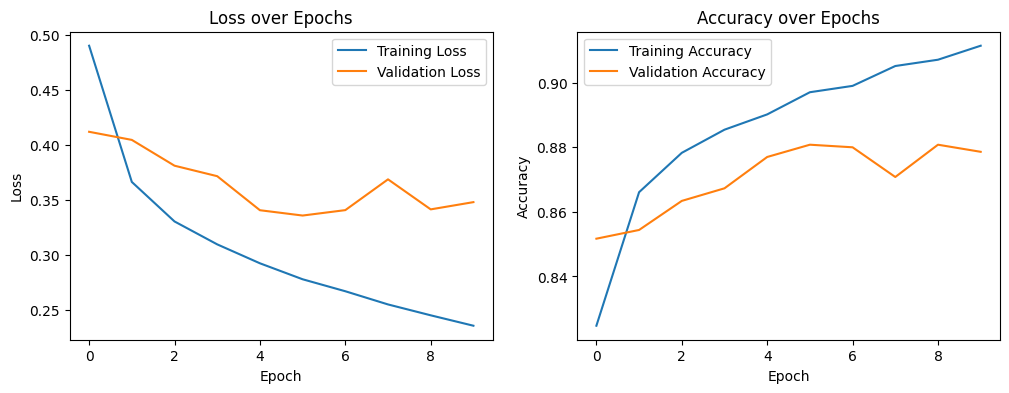

In [39]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

After building the DL model, we evaluated it and achieved **87.86% accuracy**.

## 5. Model 2: Dense Network with Flattened Input (SGD Optimizer)
This section builds another simple dense network, but this time explicitly using the pre-flattened input data and a Stochastic Gradient Descent (SGD) optimizer.

### 5.1 Model Architecture
This model takes the pre-flattened input directly (shape 784), followed by two `Dense` layers with ReLU activation and a softmax output layer for classification.

In [41]:
# Reshape the data
train_x_flattened = x_train.reshape(len(x_train),28*28)
test_x_flattened = x_test.reshape(len(x_test),28*28)

In [43]:
x_train.shape, train_x_flattened.shape

((60000, 28, 28), (60000, 784))

In [44]:
x_test.shape, test_x_flattened.shape

((10000, 28, 28), (10000, 784))

In [48]:
# Keras Model training
model=tf.keras.Sequential([
    tf.keras.Input(shape=(784,)), # Explicitly define the input shape
    tf.keras.layers.Dense(20,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

### 5.2 Model Compilation
 The model is compiled with the SGD optimizer, `sparse_categorical_crossentropy` loss, and 'accuracy' metric.

In [49]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 5.3 Model Training
 The model is trained for 10 epochs using the flattened training data, with validation on the flattened test data.

In [51]:
# Train the model
history=model.fit(train_x_flattened,y_train,epochs=10,validation_data=(test_x_flattened,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8479 - loss: 0.4380 - val_accuracy: 0.8401 - val_loss: 0.4631
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8514 - loss: 0.4245 - val_accuracy: 0.8387 - val_loss: 0.4583
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8563 - loss: 0.4127 - val_accuracy: 0.8350 - val_loss: 0.4671
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8583 - loss: 0.4042 - val_accuracy: 0.8479 - val_loss: 0.4404
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8610 - loss: 0.3954 - val_accuracy: 0.8406 - val_loss: 0.4455
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8641 - loss: 0.3877 - val_accuracy: 0.8526 - val_loss: 0.4244
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8660 - loss: 0.3808 - val_accuracy: 0.8508 - val_loss: 0.4304
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8678 - loss: 0.3753 - 

### 5.4 Model Evaluation and Visualization
 The performance of this model is evaluated, and its training history is plotted to show the learning curves for loss and accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.4141
Test Loss: 0.4141
Test Accuracy: 0.8529


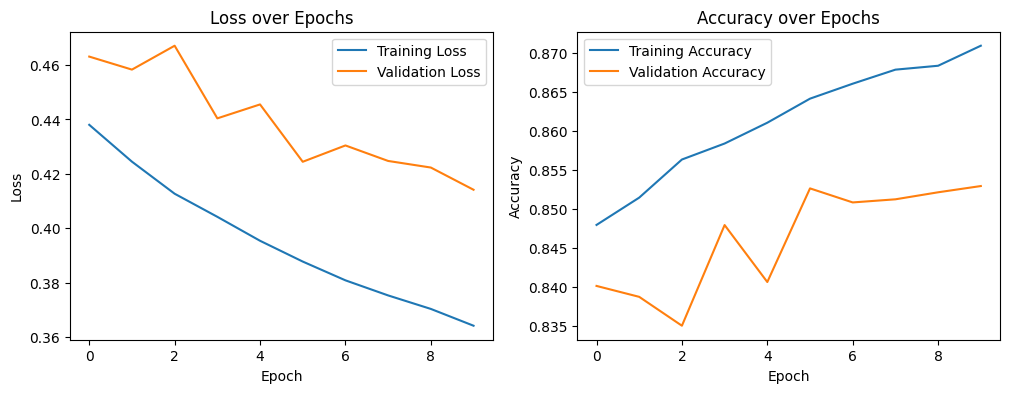

In [53]:
loss, accuracy = model.evaluate(test_x_flattened, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

After building the DL model, we evaluated it and achieved **85.29% accuracy**.

## 6. Model 3: Dense Network with Dropout and Callbacks (Adam Optimizer)
This section introduces a more robust model architecture that includes a dropout layer to prevent overfitting and utilizes Keras callbacks (EarlyStopping, ReduceLROnPlateau) to optimize the training process.

### 6.1 Model Architecture
This model incorporates a `Dropout` layer after a dense layer to introduce regularization, reducing reliance on specific neurons and improving generalization. The input is pre-flattened.

In [57]:
# Keras Model training with ading dropuot layer
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])
print("Model architecture updated successfully, addressing input_shape warning.")

Model architecture updated successfully, addressing input_shape warning.


### 6.2 Model Compilation
 The model is compiled using the Adam optimizer, `sparse_categorical_crossentropy` loss, and 'accuracy' metric.

In [58]:
# model compile using optimiser "adam"
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [62]:
# Train the model
history=model.fit(train_x_flattened,y_train,epochs=9,validation_data=(test_x_flattened,y_test))

Epoch 1/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9016 - loss: 0.2651 - val_accuracy: 0.8838 - val_loss: 0.3396
Epoch 2/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9044 - loss: 0.2576 - val_accuracy: 0.8830 - val_loss: 0.3522
Epoch 3/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9053 - loss: 0.2523 - val_accuracy: 0.8834 - val_loss: 0.3591
Epoch 4/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9083 - loss: 0.2429 - val_accuracy: 0.8859 - val_loss: 0.3380
Epoch 5/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9103 - loss: 0.2394 - val_accuracy: 0.8842 - val_loss: 0.3469
Epoch 6/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9110 - loss: 0.2355 - val_accuracy: 0.8809 - val_loss: 0.3709
Epoch 7/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9148 - loss: 0.2275 - val_accuracy: 0.8804 - val_loss: 0.3653
Epoch 8/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9148 - loss: 0.2238 - val_ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8893 - loss: 0.3681
Test Loss: 0.3681
Test Accuracy: 0.8893


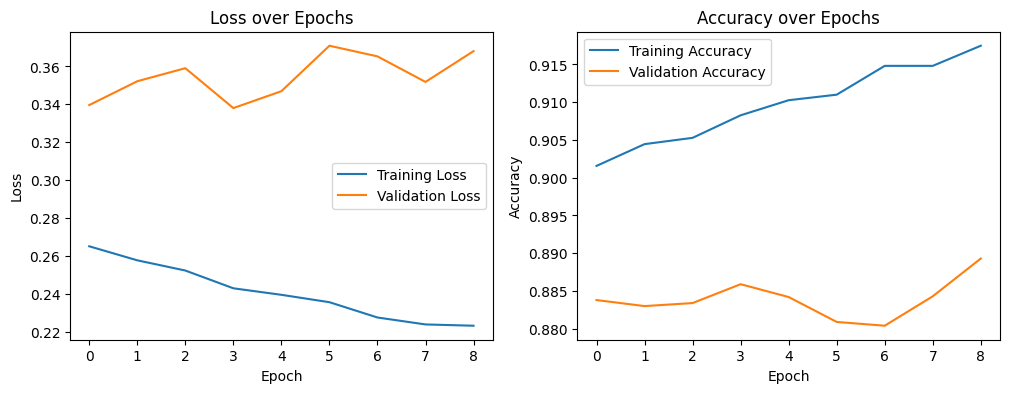

In [63]:
loss, accuracy = model.evaluate(test_x_flattened, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 6.3 Callbacks Definition
 We define two callbacks: `EarlyStopping` to stop training when validation loss stops improving (preventing overfitting), and `ReduceLROnPlateau` to decrease the learning rate when validation loss plateaus (aiding convergence).

In [64]:
from tensorflow .keras. callbacks import EarlyStopping, ReduceLROnPlateau

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=2,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.0001        # Lower bound on the learning rate
)

callbacks = [early_stopping, reduce_lr]

Now, let's retrain the model with these callbacks applied. I'll use the same model architecture and compilation, but the training process will be managed by the `EarlyStopping` and `ReduceLROnPlateau` callbacks to potentially achieve better convergence and prevent overfitting.

### 6.4 Model Training with Callbacks
 The model is trained with the defined callbacks. `EarlyStopping` will monitor `val_loss` and stop training if it doesn't improve for 3 epochs, restoring the best weights. `ReduceLROnPlateau` will reduce the learning rate if `val_loss` doesn't improve for 2 epochs.

In [65]:
# Train the model with callbacks
print("Training model with EarlyStopping and ReduceLROnPlateau callbacks...")
history_with_callbacks = model.fit(
    train_x_flattened, y_train,
    epochs=20, # Set a higher number of epochs, EarlyStopping will manage when to stop
    validation_data=(test_x_flattened, y_test),
    callbacks=callbacks
)

print("Model training with callbacks completed.")

Training model with EarlyStopping and ReduceLROnPlateau callbacks...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9171 - loss: 0.2191 - val_accuracy: 0.8842 - val_loss: 0.3483 - learning_rate: 0.0010
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9205 - loss: 0.2097 - val_accuracy: 0.8845 - val_loss: 0.3889 - learning_rate: 0.0010
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9210 - loss: 0.2088 - val_accuracy: 0.8898 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9347 - loss: 0.1703 - val_accuracy: 0.8946 - val_loss: 0.3512 - learning_rate: 2.0000e-04
Model training with callbacks completed.


### 6.5 Model Evaluation and Visualization
 The final model performance after training with callbacks is evaluated, and the training history (loss and accuracy) is visualised to observe the impact of the callbacks on the learning process.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8842 - loss: 0.3483
Test Loss (with callbacks): 0.3483
Test Accuracy (with callbacks): 0.8842


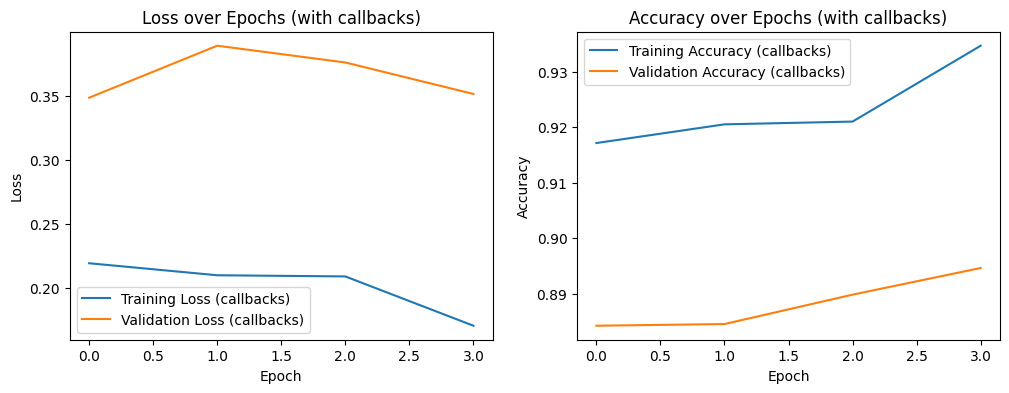

In [66]:
# Evaluate the model after training with callbacks
loss_cb, accuracy_cb = model.evaluate(test_x_flattened, y_test)
print(f'Test Loss (with callbacks): {loss_cb:.4f}')
print(f'Test Accuracy (with callbacks): {accuracy_cb:.4f}')

# Plot training history with callbacks
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_with_callbacks.history['loss'], label='Training Loss (callbacks)')
plt.plot(history_with_callbacks.history['val_loss'], label='Validation Loss (callbacks)')
plt.title('Loss over Epochs (with callbacks)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_with_callbacks.history['accuracy'], label='Training Accuracy (callbacks)')
plt.plot(history_with_callbacks.history['val_accuracy'], label='Validation Accuracy (callbacks)')
plt.title('Accuracy over Epochs (with callbacks)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

After building the DL model, we evaluated it and achieved **88.42% accuracy**.

In [67]:
loss,acc = model.evaluate(test_x_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8842 - loss: 0.3483


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Text(0.5, 1.0, 'Actual: 6| predicted: 6')

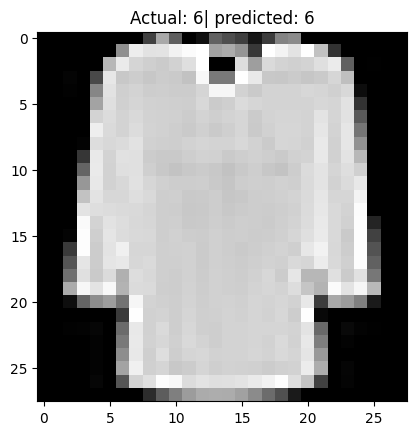

In [70]:
pred = model.predict(test_x_flattened)

index = 145

plt.imshow(x_test[index],cmap ='gray')
plt.title(f"Actual: {y_test[index]}| predicted: {np.argmax(pred[index])}")